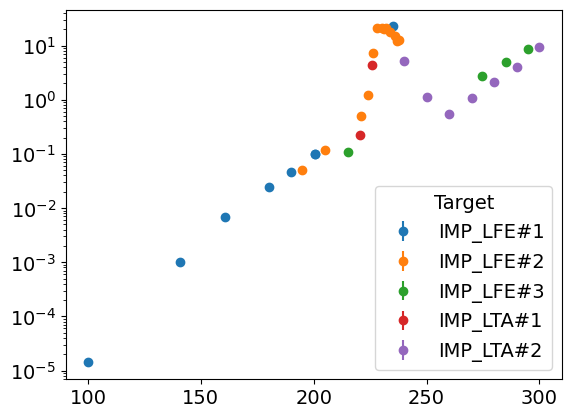

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
import pandas as pd

df = pd.read_csv('Yield_6130_total.csv')
# Remove from target SUDF#X
df = df[~df['Target'].str.contains('SUDF')]

eff = 0.6953924699999998  # detection efficiency
E, Y, Y_err = df['Energy'].values, df['Y'].values/eff, df['Y_error'].values/eff

M0, M1 = 1.007276466621, 18.9984031636

def lab_to_cm(E_lab):
    return E_lab * M1 / (M0 + M1)

def cm_to_lab(E_cm):
    return E_cm * (M0 + M1) / M1

plt.yscale('log')
for target, group in df.groupby('Target'):
    plt.errorbar(group['Energy'], group['Y'], yerr=group['Y_error'], label=str(target), fmt='o', markersize=6)
plt.legend(title='Target')
plt.show()

[ 983  983 1009 1010 1011 1012 1013 1516 1564 1589 1614 1917 1989 2460
 2565 2592 2617]


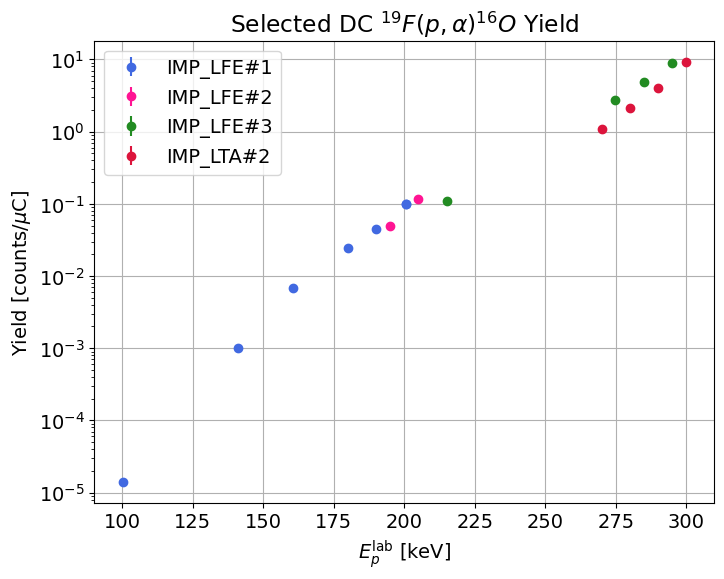

100.144 --> 	 0.00002 +/- 0.00000 	 IMP_LFE#1 	 Scan 2
140.876 --> 	 0.00147 +/- 0.00004 	 IMP_LFE#1 	 Scan 2
160.615 --> 	 0.00973 +/- 0.00014 	 IMP_LFE#1 	 Scan 2
179.969 --> 	 0.03476 +/- 0.00031 	 IMP_LFE#1 	 Scan 2
189.982 --> 	 0.06533 +/- 0.00057 	 IMP_LFE#1 	 Scan 2
194.966 --> 	 0.07136 +/- 0.00009 	 IMP_LFE#2 	 Scan 6
200.709 --> 	 0.14421 +/- 0.00013 	 IMP_LFE#1 	 Scan 1
200.709 --> 	 0.14354 +/- 0.00013 	 IMP_LFE#1 	 Scan 1
205.022 --> 	 0.16956 +/- 0.00014 	 IMP_LFE#2 	 Scan 8
215.060 --> 	 0.15696 +/- 0.00016 	 IMP_LFE#3 	 Scan1
270.079 --> 	 1.54533 +/- 0.00037 	 IMP_LTA#2 	 Scan 4
274.600 --> 	 3.93382 +/- 0.00047 	 IMP_LFE#3 	 Scan 5
280.001 --> 	 3.05843 +/- 0.00056 	 IMP_LTA#2 	 Scan 3
285.030 --> 	 7.11460 +/- 0.00066 	 IMP_LFE#3 	 Scan 6
290.001 --> 	 5.77867 +/- 0.00073 	 IMP_LTA#2 	 Scan 2
294.980 --> 	 12.67336 +/- 0.00089 	 IMP_LFE#3 	 Scan 7
299.999 --> 	 13.35054 +/- 0.00151 	 IMP_LTA#2 	 Scan 1


In [2]:
# Select only the yield E<220 and E>260
from pdb import run
from turtle import color


mask = (E < 216) | (E > 260)
E_filtered = E[mask]
Y_filtered = Y[mask]
Y_err_filtered = Y_err[mask]
targets = df['Target'].values[mask]
scans = df['Scan'].values[mask]
runnumber = df['Run'].values[mask]

# df = df[(df['Energy'] < 210) | (df['Energy'] > 260)]
# print(df)

idx = np.argsort(E_filtered)
E_filtered = E_filtered[idx]
Y_filtered = Y_filtered[idx]
Y_err_filtered = Y_err_filtered[idx]
targets = targets[idx]
scans = scans[idx]
runnumber = runnumber[idx]
print(np.sort(runnumber))

plt.figure(figsize=(8,6))
plt.title(r'Selected DC ${}^{19}F(p,\alpha){}^{16}O$ Yield')
plt.yscale('log')
my_color = ['royalblue', 'deeppink', 'forestgreen', 'crimson']
for target, group in df[mask].groupby('Target'):
    plt.errorbar(group['Energy'], group['Y'], yerr=group['Y_error'], label=str(target), fmt='o', markersize=6, color=my_color.pop(0))

plt.xlabel(r'$E_p^{\text{lab}}$ [keV]')
plt.ylabel(r'Yield [counts/$\mu$C]')
plt.legend()
plt.grid()
plt.savefig('Selected_yield_19F_pa_16O_total_DC.png', dpi=300, bbox_inches='tight')
plt.show()

for i in range(len(E_filtered)):
    print(f"{E_filtered[i]:.3f} --> \t {Y_filtered[i]:.5f} +/- {Y_err_filtered[i]:.5f} \t {targets[i]} \t {scans[i]}")

Doppler effect = 0.02839149987232094


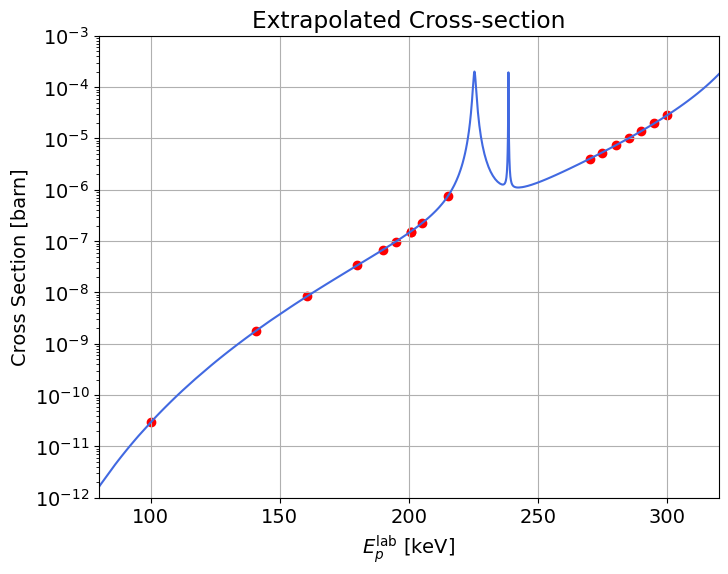

1
IMP_LFE#1 Scan 2
Using parameters: n_backing=0.7994101560019959, mean=1.8392994658832384, std=7.174543607840262, alpha=5.0
95.137 --> 	 Cross-Section derived: 0.00002 	 Experimental derived: 0.00002 	 Ratio: 1.18463
1
IMP_LFE#1 Scan 2
Using parameters: n_backing=0.7994101560019959, mean=1.8392994658832384, std=7.174543607840262, alpha=5.0
133.832 --> 	 Cross-Section derived: 0.00122 	 Experimental derived: 0.00147 	 Ratio: 1.20650
1
IMP_LFE#1 Scan 2
Using parameters: n_backing=0.7994101560019959, mean=1.8392994658832384, std=7.174543607840262, alpha=5.0
152.584 --> 	 Cross-Section derived: 0.00602 	 Experimental derived: 0.00973 	 Ratio: 1.61564
1
IMP_LFE#1 Scan 2
Using parameters: n_backing=0.7994101560019959, mean=1.8392994658832384, std=7.174543607840262, alpha=5.0
170.971 --> 	 Cross-Section derived: 0.02489 	 Experimental derived: 0.03476 	 Ratio: 1.39670
1
IMP_LFE#1 Scan 2
Using parameters: n_backing=0.7994101560019959, mean=1.8392994658832384, std=7.174543607840262, alpha=5.0


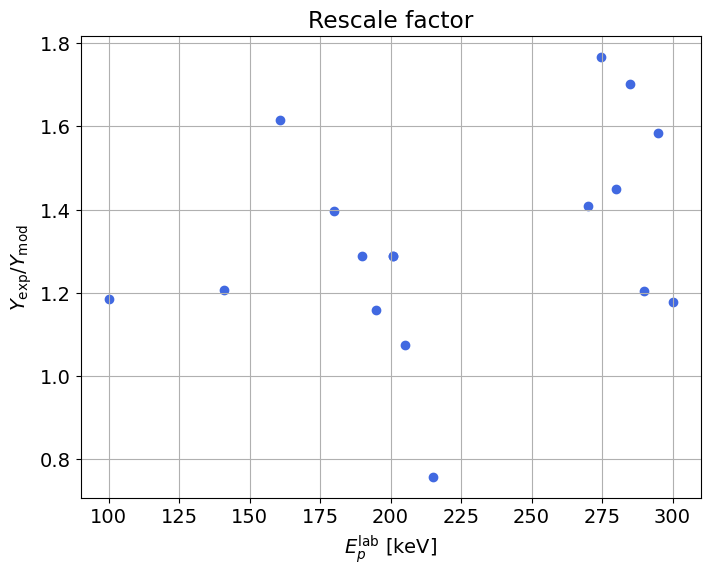

In [3]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from SRIM import SRIM
from scipy.special import erf
from scipy import integrate

warnings.filterwarnings('ignore')

# Select target
target = 'IMP_LTA#2'

# Boltzmann constant in keV/K
k = 8.617e-5

# Doppler effect
dopp = np.sqrt( 2 * 1.007 / 19 * 0.250 * k * ( 80 + 273 ) )

print( 'Doppler effect =', dopp )

# Read the element stopping data
H_in_F = SRIM( "stopping/H_in_F.stop" )
H_in_H = SRIM( "stopping/H_in_H.stop" )
H_in_Fe = SRIM( "stopping/H_in_Fe.stop" )
H_in_Ta = SRIM( "stopping/H_in_Ta.stop" )
H_in_Ca = SRIM( "stopping/H_in_Ca.stop" )

# Get the effective stopping power for CaF2
def effective_stopping_CaF2( energy, n_inactive=1, n_active=2 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ca.eval( energy )

# Get the effective stopping power for F implanted in Fe
def effective_stopping_Fe( energy, n_inactive=1, n_active=3 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Fe.eval( energy )

# Get the effective stopping power for F implanted in Ta
def effective_stopping_Ta( energy, n_inactive=1, n_active=5 ):
    stoichiometry = n_inactive / n_active
    return H_in_F.eval( energy ) + stoichiometry * H_in_Ta.eval( energy )

# Starggling
popt = [0.75324712]
def straggling( x ):
    return popt[0] * np.sqrt( x )

def gaussian( x, x0, s ):
    return np.exp( -(x - x0)**2 / ( s*s*2 ) )

def log_normal( x, x0, s ):
    return ( 1 / ( x * s * np.sqrt( 2 * np.pi ) ) ) * np.exp( - ( np.log( x ) - x0 )**2 / ( 2 * s**2 ) )

def profile( de, theta ):
    # Gaussian
    if de <= 0: return 0
    else: return gaussian( de, theta["mean"], theta["std"] )

    # # Square
    # return 1 if de > 0 and de < theta["width"] else 0

data = np.loadtxt( f"utils/all_imp.extrap", usecols=(0,3))

energies, extrap = data[:,0], data[:,1]
plt.figure(figsize=(8,6))
plt.title('Extrapolated Cross-section')
plt.yscale('log')
plt.plot( energies*(M0+M1)/M1*1e3, extrap, color='royalblue' )
plt.scatter(E_filtered, np.interp( E_filtered, energies*(M0+M1)/M1*1e3, extrap ), color='red')
plt.xlim(80, 320)
plt.ylim(1e-12, 1e-3)
plt.xlabel(r'$E_p^{\text{lab}}$ [keV]')
plt.ylabel(r'Cross Section [barn]')
plt.grid()
plt.savefig('Extrapolated_cross_section_19F_pa_16O_total_DC.png', dpi=300, bbox_inches='tight')
plt.show()

def cross_section( x0, theta, de ):
    cross = np.interp( x0, energies * 1e3, extrap )
    return cross 

def reaction_yield( x0, theta, de ):
    cross = cross_section( x0, theta, de ) * 1e-24
    if 'FE' in target:
        stop = effective_stopping_Fe( x0, theta["n_backing"], theta["n_f"] ) * 1e-15 * 1e-3
    elif 'TA' in target:
        stop = effective_stopping_Ta( x0, theta["n_backing"], theta["n_f"] ) * 1e-15 * 1e-3
    else:
        stop = effective_stopping_Ta( x0, theta["n_backing"], theta["n_f"] ) * 1e-15 * 1e-3
    p = profile( de, theta )
    return cross / stop * p

def integrand( x, theta, x0 ):
    de = x0 - x
    
    # Get beam width
    s = np.sqrt( pow( theta["beam"], 2 ) + pow( dopp, 2 ) )
    s = np.sqrt( pow( theta["strag"] * straggling( de ), 2 ) + pow(s, 2) ) if de > 0 else s

    # Convolve the gaussian with the straggling
    array = np.linspace( x - 3 * s, x + 3 * s, 100 )
    gauss = gaussian( array, x, s )

    # Normalize the gaussian
    step = array[1] - array[0]
    norm  = np.sum( gauss ) * step
    
    # Convolve
    conv = np.sum( gauss * reaction_yield( array, theta, de ) ) * step / norm

    #return reaction_yield( x, theta, de )
    return conv

def straggled_profile( x, theta ):
    print(len(x))
    y = np.zeros( shape=len( x ) )
    for idx in range( len( x ) ):
        nsteps = 500
        xmin, xmax = x[idx] - 50, x[idx]
        dx = np.abs( xmax - xmin ) / nsteps
        y[idx] = integrate.simpson( [ integrand( x_i, theta, x[idx] ) for x_i in np.linspace( xmin, xmax, nsteps) ], dx=dx )
    return y

def model( x, theta ):
    sign = straggled_profile( x, theta )
    back = 0
    return sign + back

q_e = 1.602176634e-19

y_calc_list = []
ratio_list = [[],[],[]]
for E in E_filtered:
    df_params_240 = pd.read_csv('/data0/biasissi/LUNA/19F+p_g+20Ne/Computations/Profile/results/fit_params_240.csv')
    # df_params_340 = pd.read_csv('/data0/biasissi/LUNA/19F+p_g+20Ne/Computations/Profile/results/fit_params_340.csv')

    # filter df_params_XXX for the target and scan of associated E in E_filtered
    target_E = targets[np.where(E_filtered == E)[0][0]]
    scan_E = scans[np.where(E_filtered == E)[0][0]]
    df_params_240 = df_params_240[( df_params_240['target'] == target_E) & (df_params_240['scan'] == scan_E)]
    # print(df_params_240)
    # df_params_340 = df_params_340[(df_params_340['target'] == target_E) & (df_params_340['scan'] == scan_E)]
    # print(df_params_340)

    if len(df_params_240) == 0:
        df_params_240 = pd.read_csv('/data0/biasissi/LUNA/19F+p_g+20Ne/Computations/Profile/results/fit_params_240.csv')
        df_params_240 = df_params_240[ df_params_240['target'] == target_E ]
        if len(df_params_240) == 0:
            continue
        elif len(df_params_240) == 1:
            n_backing = df_params_240['n_backing'].values[0]
            mean = df_params_240['mean'].values[0]
            std = df_params_240['std'].values[0]
            alpha = df_params_240['alpha'].values[0]

    elif len(df_params_240) == 1:
        n_backing = df_params_240['n_backing'].values[0]
        mean = df_params_240['mean'].values[0]
        std = df_params_240['std'].values[0]
        alpha = df_params_240['alpha'].values[0]

    # if len(df_params_240) != 0: #and len(df_params_340) != 0:
    #     n_backing = df_params_240['n_backing'].values[0]
    #     mean = df_params_240['mean'].values[0]
    #     std = df_params_240['std'].values[0]
    #     alpha = df_params_240['alpha'].values[0]

        # n_backing_340 = df_params_340['n_backing'].values[0]
        # mean_340 = df_params_340['mean'].values[0]
        # std_340 = df_params_340['std'].values[0]
        # alpha_340 = df_params_340['alpha'].values[0]

        # n_backing = ( n_backing_240 + n_backing_340 ) / 2
        # mean = ( mean_240 + mean_340 ) / 2
        # std = ( std_240 + std_340 ) / 2
        # alpha = ( alpha_240 + alpha_340 ) / 2
    # elif len(df_params_240) != 0 and len(df_params_340) == 0:
    #     n_backing = df_params_240['n_backing'].values[0]
    #     mean = df_params_240['mean'].values[0]
    #     std = df_params_240['std'].values[0]
    #     alpha = df_params_240['alpha'].values[0]
    # elif len(df_params_240) == 0 and len(df_params_340) != 0:
    #     n_backing = df_params_340['n_backing'].values[0]
    #     mean = df_params_340['mean'].values[0]
    #     std = df_params_340['std'].values[0]
    #     alpha = df_params_340['alpha'].values[0]
    # else:
    #     df_params_240 = pd.read_csv('/data0/biasissi/LUNA/19F+p_g+20Ne/Computations/Profile/results/fit_params_240.csv')
    #     df_params_240 = df_params_240[ df_params_240['target'] == target_E ]
    #     scans = df_params_240['scan'].values
    #     print(scans)
    #     closest_scan = min( scans, key=lambda x: abs(x - scan_E) )
    #     df_params_240 = df_params_240[ df_params_240['scan'] == closest_scan ]
    #     n_backing = df_params_240['n_backing'].values[0]
    #     mean = df_params_240['mean'].values[0]
    #     std = df_params_240['std'].values[0]
    #     alpha = df_params_240['alpha'].values[0]
    
    theta = {
        "beam": 0.12,
        "strag": 1.0,
        "n_backing": n_backing,
        "n_f": 1.0,
        "mean": mean,
        "std": std,
        "alpha": alpha
    }
    # p = []
    # for de in np.linspace(-10, 60, 100):
    #     p.append( profile( de, theta ) )
    # de_max = np.linspace(-10, 60, 100)[ np.where( p == np.max(p) )[0][0] ]
    # print(f"Profile maximum at de = {de_max:.3f} keV")
    # y_calc = reaction_yield(E*19/20, theta,
    #     de=de_max) / q_e / 1e6 * eff
    theta_new = theta.copy()
    if 'FE' in target:
        stopp_ref = effective_stopping_Fe( 240, theta["n_backing"], theta["n_f"] ) * 1e-15 * 1e-3
        stop = effective_stopping_Fe( E, theta["n_backing"], theta["n_f"] ) * 1e-15 * 1e-3
        stop_ratio = stop / stopp_ref
    elif 'TA' in target:
        stopp_ref = effective_stopping_Ta( 240, theta["n_backing"], theta["n_f"] ) * 1e-15 * 1e-3
        stop = effective_stopping_Ta( E, theta["n_backing"], theta["n_f"] ) * 1e-15 * 1e-3
        stop_ratio = stop / stopp_ref
    else:
        stopp_ref = effective_stopping_Ta( 240, theta["n_backing"], theta["n_f"] ) * 1e-15 * 1e-3
        stop = effective_stopping_Ta( E, theta["n_backing"], theta["n_f"] ) * 1e-15 * 1e-3
        stop_ratio = stop / stopp_ref
    theta_new["mean"] = theta["mean"] * stop_ratio
    theta_new["std"] = theta["std"] * stop_ratio
    y_calc = model( np.array( [ E*18.9984031636/(1.007276466621+18.9984031636) ] ), theta )[0] / q_e / 1e6 * eff
    y_calc_list.append( y_calc )
    ratio_list[0].append( Y_filtered[np.where(E_filtered == E)[0][0]] / y_calc )
    ratio_list[1].append( (Y_filtered[np.where(E_filtered == E)[0][0]]-Y_err_filtered[np.where(E_filtered == E)[0][0]])/y_calc )
    ratio_list[2].append( (Y_filtered[np.where(E_filtered == E)[0][0]]+Y_err_filtered[np.where(E_filtered == E)[0][0]])/y_calc )
    print(target_E, scan_E)
    print(f"Using parameters: n_backing={n_backing}, mean={mean}, std={std}, alpha={alpha}")
    print(f"{E*19/20:.3f} --> \t Cross-Section derived: {y_calc:.5f} \t Experimental derived: {Y_filtered[np.where(E_filtered == E)[0][0]]:.5f} \t Ratio: {Y_filtered[np.where(E_filtered == E)[0][0]] / y_calc :.5f}")
    print("============================")

# Build numpy arrays and align lengths for plotting and further calculations
ratios0 = np.array(ratio_list[0])
ratios_min = np.array(ratio_list[1])
ratios_max = np.array(ratio_list[2])

n = ratios0.size
if n == 0:
    print("No ratios computed; nothing to plot or rescale.")
    E_plot = np.array([])
    targets_plot = np.array([])
else:
    E_plot = E_filtered[:n]
    targets_plot = targets[:n]

y_calc_array = np.array( y_calc_list )
ratio_array = np.array( ratio_list )
print(ratio_array[0])

# Drop he 2nd and 3rd (starting with 0) values
# ratio_array = np.delete(ratio_array, [3,4])
# E_filtered_dropped = np.delete(E_filtered, [3,4])


if n > 0:
    plt.figure(figsize=(8,6))
    plt.title('Rescale factor')
    plt.scatter( E_plot, ratios0, color='royalblue' )
    plt.xlabel(r'$E_p^{\text{lab}}$ [keV]')
    plt.ylabel(r'$Y_{\text{exp}} / Y_{\text{mod}}$')
    plt.grid()
    plt.savefig('Rescale_factor_19F_pa_16O_total_DC.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Skipping ratio plot; no data available')

# ratio_min, ratio_max = 

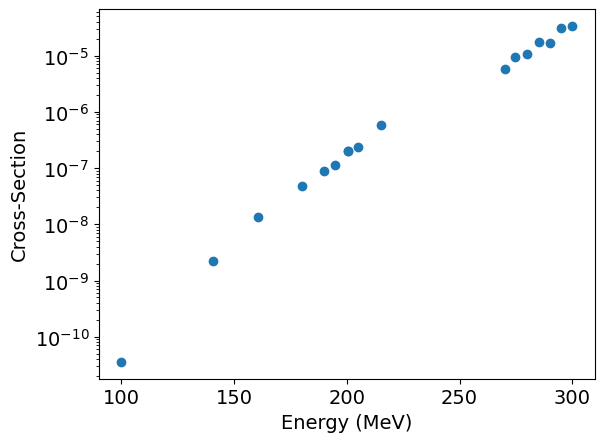

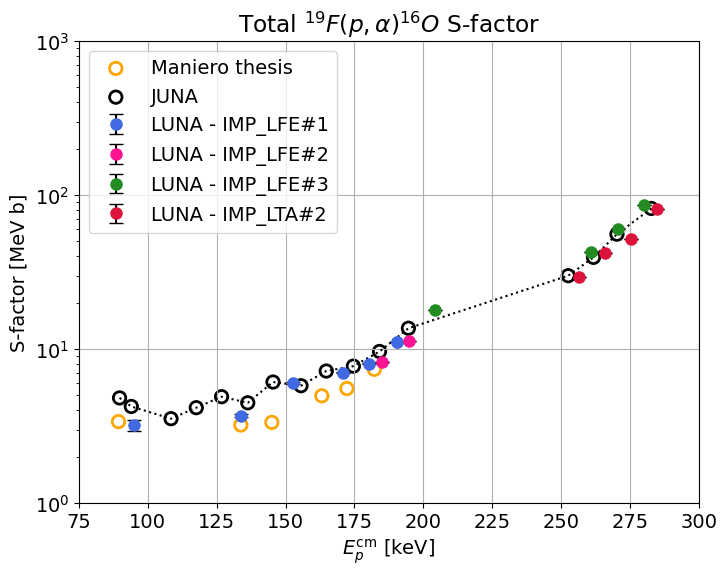

[ 89.76248976  94.02129402 108.43570844 117.60851761 126.78132678
 136.28173628 145.45454545 155.61015561 164.78296478 174.61097461
 184.11138411 194.59459459 252.57985258 261.75266175 270.27027027
 282.71908272]
[ 3.2062744   3.2062744   3.37361582  3.48873307  3.60385031  4.00558698
  5.1577686   6.21066317  6.69996794  7.41149644  8.1993832  11.19936023
 28.6114207  42.67143615 58.44232816 83.43372147]
[-33.40202804 -24.31382461  -4.3958869  -16.12739682 -26.49945595
 -10.48980235 -15.52123264   7.45662948  -6.90424731  -4.27684257
 -14.95393976 -17.91334114  -4.4239788    8.36752745   4.88074473
   2.01010687]
-9.781685522864592


In [4]:
# Use E_plot (aligned energies) for rescaling if available

maniero_e, maniero_S = [182.23, 172.27, 163.15, 145.02, 133.78, 89.38], [7.38,5.54, 4.97, 3.34, 3.21, 3.38]

if 'E_plot' not in globals() or E_plot.size == 0:
    print('No aligned energy/ration pairs available; skipping rescale and S-factor plotting')
    cross_section_rescaled = np.array([])
    cross_section_rescaled_min = np.array([])
    cross_section_rescaled_max = np.array([])
else:
    cross_section_rescaled = np.interp( E_plot*19/20, energies * 1e3, extrap )
    # ensure ratios arrays exist and are aligned
    r0 = ratios0[:cross_section_rescaled.size]
    rmin = ratios_min[:cross_section_rescaled.size]
    rmax = ratios_max[:cross_section_rescaled.size]
    cross_section_rescaled_min = cross_section_rescaled * rmin
    cross_section_rescaled_max = cross_section_rescaled * rmax
    cross_section_rescaled = cross_section_rescaled * r0

# plot rescaled cross section if data exists
if cross_section_rescaled.size > 0:
    plt.yscale('log')
    plt.plot( E_plot, cross_section_rescaled, 'o', label='Cross Section Rescaled by yield ratios' )
    plt.xlabel('Energy (MeV)')
    plt.ylabel('Cross-Section')
    plt.show()

M0, M1 = 1.007276466621, 18.9984031636
Z0, Z1 = 1, 9

# use E_plot for S-factor calculation; if empty, skip
if 'E_plot' in globals() and E_plot.size > 0:
    exponentials = 0.98951013 * Z0 * Z1 * np.sqrt((M0*M1)/(M0+M1) * 1e3/E_plot)

    df_JUNA = pd.read_csv('JUNA_S_factor.csv')
    mask = (df_JUNA['E_cm'] < 290) & (df_JUNA['E_cm'] > 80)
    E_JUNA = df_JUNA.loc[mask, 'E_cm'].values
    S_JUNA = df_JUNA.loc[mask, 'S_factor'].values

    df_SP00 = pd.read_csv('theoretical_SP00.csv')
    SP00_E, S_SP00 = df_SP00['E_cm'].values, df_SP00['S_factor'].values

    s_factor = cross_section_rescaled * E_plot/1e3 / np.exp(-exponentials)
    s_factor_min = cross_section_rescaled_min * E_plot/1e3 / np.exp(-exponentials)
    s_factor_max = cross_section_rescaled_max * E_plot/1e3 / np.exp(-exponentials)

    plt.figure(figsize=(8,6))
    plt.title(r'Total ${}^{19}F(p,\alpha){}^{16}O$ S-factor')
    plt.yscale('log')
    colors = {'IMP_LFE#1': 'royalblue', 'IMP_LFE#2': 'deeppink', 'IMP_LFE#3': 'forestgreen', 'IMP_LTA#2': 'crimson'}
    for target in np.unique(targets_plot):
        target_mask = (targets_plot == target)
        plt.errorbar(
            E_plot[target_mask] * M1 / (M0 + M1),
            s_factor[target_mask],
            yerr=[
                s_factor[target_mask] - s_factor_min[target_mask],
                s_factor_max[target_mask] - s_factor[target_mask]
            ],
            fmt='o',
            capsize=5,
            ecolor='black',
            label=f'LUNA - {target}',
            color=colors.get(target, 'black'),
            markersize=8
        )
    plt.scatter(maniero_e, maniero_S, label='Maniero thesis', color='orange', s=80, facecolors='none', edgecolors='orange', linewidths=2)
    plt.scatter(E_JUNA, S_JUNA, label='JUNA', color='black', s=80, facecolors='none', edgecolors='black', linewidths=2)
    plt.plot(E_JUNA, S_JUNA, ls='dotted', c='black')
    plt.xlabel(r"$E_p^{\text{cm}}$ [keV]")
    plt.ylabel(r"S-factor [MeV b]")
    plt.grid()
    plt.legend(loc='upper left')
    plt.xlim(75, 300)
    plt.ylim(1e0, 1e3)
    plt.savefig('S_factor_19F_pa_16O_total_DC.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No rescaled cross-section / S-factor to plot.')

# Perform comparison between LUNA and JUNA S-factors
print(E_JUNA)
LUNA_on_JUNA = np.interp( E_JUNA, E_plot * M1 / (M0 + M1), s_factor )
print(LUNA_on_JUNA)

LUNA_on_JUNA = np.array(LUNA_on_JUNA)
S_JUNA = np.array(S_JUNA)
differences = (LUNA_on_JUNA - S_JUNA)/S_JUNA*100
print(differences)
print(np.mean(differences))